## Quality Processes for Texts

In [11]:
#!pip install langdetect googletrans deep_translator

In [97]:
# Importing useful dependencies
import re
import unicodedata

import boto3
import chardet
import pandas as pd
import tiktoken
from langdetect import detect_langs, detect
from deep_translator import GoogleTranslator
# set tokenizer with openAI standard token
from typing import List, Dict
from ftfy import fix_text
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [75]:
# Setup S3 client for MinIO (MinIO implements Amazon S3 API)
s3 = boto3.client(
    "s3",
    endpoint_url="http://127.0.0.1:9000", # MinIO API endpoint
    aws_access_key_id="minioadmin", # User name
    aws_secret_access_key="minioadmin", # Password
)

In [76]:
# Constant and function will support quality check
#Control characters
CTRL_RE = re.compile(r'[\x00-\x08\x0B\x0C\x0E-\x1F\x7F]')
BIDI_RE = re.compile(r'[\u202A-\u202E\u2066-\u2069]')

# check api keys, and personal information
PII_PATTERNS = {
    "email": r"[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}",
    "phone": r"\b(?:\+?\d{1,3}[-.\s]?)?(?:\(?\d{2,4}\)?[-.\s]?)?\d{3,4}[-.\s]?\d{3,4}\b"
}
SECRET_PATTERNS = {
    "api_key": r"\b(sk-|AKIA|AIza)[A-Za-z0-9-_]{10,}\b"
}

def language_check(text):
    try:
        langs = detect_langs(text) 
        language_probs = {str(l.lang): l.prob for l in langs}
        mixed_language = len(language_probs) > 1 and max(language_probs.values()) < 0.95
    except Exception:
        language_probs, mixed_language = {}, False
    return language_probs, mixed_language

In [112]:
# ---- Quality checks ----
def check_text_quality(body: bytes, key: str):
    """Return a simple dict of basic quality stats for one file."""
    if not body:
        return {"key": key, "empty": True}
    
    # detect encoding and decode safely
    guess = chardet.detect(body)
    enc = guess.get("encoding") or "utf-8"
    encoding_confidence = guess.get("confidence", 0.0)
    has_bom = body.startswith((b'\xef\xbb\xbf', b'\xff\xfe', b'\xfe\xff'))

    text = body.decode(enc, errors="replace")
    # check control character
    control_char_ratio = len(CTRL_RE.findall(text)) / max(1, len(text))
    has_null_bytes = '\x00' in text
    bidi_ctrl_count = len(BIDI_RE.findall(text))
    # check line endings
    line_endings = {
        "LF": text.count("\n"),
        "CRLF": text.count("\r\n"),
        "CR": text.count("\r") - text.count("\r\n"),
    }
    mixed_line_endings = sum(v > 0 for v in line_endings.values()) > 1
    # check printable ratio (avoid binary garbage)
    printable_ratio = sum(c.isprintable() or c.isspace() for c in text) / max(1, len(text))
    
    # check line stats
    lines = text.splitlines()
    line_lengths = [len(l) for l in lines if l.strip()]
    avg_line_len = np.mean(line_lengths) if line_lengths else 0
    p95_line_len = np.percentile(line_lengths, 95) if line_lengths else 0
    max_line_len = max(line_lengths, default=0)
    # --- Paragraph token stats ---
    paragraphs = [p.strip() for p in text.split("\n\n") if p.strip()]
    
    paragraph_tokens = [len(p) for p in paragraphs] if paragraphs else []
    
    avg_tokens_per_paragraph = (
        sum(paragraph_tokens) / len(paragraph_tokens) if paragraph_tokens else 0
    )
    max_tokens_paragraph = max(paragraph_tokens) if paragraph_tokens else 0
    min_tokens_paragraph = min(paragraph_tokens) if paragraph_tokens else 0
    # basic stats
    sentences = re.split(r"[.!?。！？]+", text)
    sentences = [s.strip() for s in sentences if s.strip()]
    sentence_count = len(sentences)

    # unicode check
    normalized_text = unicodedata.normalize("NFKC", text)
    diff = sum(1 for a, b in zip(text, normalized_text) if a != b)
    norm_changed_ratio = diff / max(1, len(text)) 
    
    # language check
    language_probs, mixed_language = language_check(text)

    
    #legislation
    pii_hits = {k: len(re.findall(v, text)) for k, v in PII_PATTERNS.items()}
    secret_hits = {k: len(re.findall(v, text)) for k, v in SECRET_PATTERNS.items()}
    stats = {
        "key": key,
    
        # === 1. Encoding Layer ===
        "size_bytes": len(body),
        "encoding": enc,
        "encoding_confidence": encoding_confidence,
        "has_bom": has_bom,
    
        # === 2. Control & Binary Layer ===
        "control_char_ratio": control_char_ratio,
        "has_null_bytes": has_null_bytes,
        "bidi_ctrl_count": bidi_ctrl_count,
        "printable_ratio": printable_ratio,
    
        # === 3. Structure Layer ===
        "lines": len(lines),
        "mixed_line_endings": mixed_line_endings,
        "avg_line_len": avg_line_len,
        "p95_line_len": p95_line_len,
        "max_line_len": max_line_len,
    
        # === 4. Readability / Paragraph Layer ===
        "paragraphs": len(paragraphs),
        "avg_tokens_per_paragraph": round(avg_tokens_per_paragraph, 2),
        "paragraph_token_list": paragraph_tokens,
        "max_tokens_paragraph": max_tokens_paragraph,
        "min_tokens_paragraph": min_tokens_paragraph,
        "sentence_count": sentence_count,
    
        # === 5. Unicode Layer ===
        "norm_changed_ratio": norm_changed_ratio,
    
        # === 6. Language Layer ===
        "language_probs": language_probs,
        "mixed_language": mixed_language,
    
        # === 7. Content Quality Layer ===
        "too_short": len(text.strip()) < 20,
        "empty": not bool(text.strip()),
    
        # === 8. Compliance Layer ===
        "pii_hits": pii_hits,
        "secret_hits": secret_hits,
    }
    return stats

In [111]:
# ---- Run checks on all txt files ----
def extract_datas(bucket,prefix=""):
    results = []
    etags=set()
    paginator = s3.get_paginator("list_objects_v2")
    for page in paginator.paginate(Bucket=bucket, Prefix=prefix):
        for obj in page.get("Contents", []):
            duplicate = False
            key = obj["Key"]
            
            size = obj["Size"]
            etag = obj["ETag"].strip('"')
            if size == 0 and key.endswith("/"): # skip the folder itself
                continue
            
            sig = (etag, size)
            if sig in etags:
                duplicate = True
            else:
                etags.add(sig)
            # Download the text
            resp = s3.get_object(Bucket=bucket, Key=key)
            body = resp["Body"].read()
            stats = check_text_quality(body, key)
            stats["duplicated"] = duplicate
            results.append(stats)
            
    return results

In [83]:
data = extract_datas(bucket = "trusted-zone", prefix = "texts")

In [84]:
# Convert the data into a dataFrame
df = pd.DataFrame(data)
df

,key,size_bytes,encoding,encoding_confidence,has_bom,control_char_ratio,has_null_bytes,bidi_ctrl_count,printable_ratio,lines,...,min_tokens_paragraph,sentence_count,norm_changed_ratio,language_probs,mixed_language,too_short,empty,pii_hits,secret_hits,duplicated
0,texts/text_1761318441201.txt,982,ascii,1.00000,False,0.0,False,0,1.000000,1,...,982,10,0.000000,{'en': 0.9999966197284513},False,False,False,"{'email': 0, 'phone': 0}",{'api_key': 0},False
1,texts/text_1761318441420.txt,4804,utf-8,0.99000,False,0.0,False,0,0.999788,1,...,4715,37,0.070414,{'en': 0.9999985476202323},False,False,False,"{'email': 0, 'phone': 0}",{'api_key': 0},False
2,texts/text_1761318441651.txt,734,utf-8,0.87625,False,0.0,False,0,1.000000,1,...,729,8,0.371742,{'en': 0.9999972296413744},False,False,False,"{'email': 0, 'phone': 0}",{'api_key': 0},False
3,texts/text_1761318441842.txt,1373,utf-8,0.75250,False,0.0,False,0,1.000000,1,...,1369,17,0.000000,{'en': 0.9999961052436038},False,False,False,"{'email': 0, 'phone': 0}",{'api_key': 0},False
4,texts/text_1761318442105.txt,2423,utf-8,0.87625,False,0.0,False,0,1.000000,1,...,2417,16,0.000000,{'en': 0.9999958467497823},False,False,False,"{'email': 0, 'phone': 0}",{'api_key': 0},False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1184,texts/text_1761413980049.txt,1046,ascii,1.00000,False,0.0,False,0,1.000000,1,...,1046,7,0.000000,{'en': 0.9999968136388344},False,False,False,"{'email': 0, 'phone': 0}",{'api_key': 0},False
1185,texts/text_1761413980535.txt,1279,ascii,1.00000,False,0.0,False,0,1.000000,1,...,1279,10,0.000000,{'en': 0.9999962120089633},False,False,False,"{'email': 0, 'phone': 0}",{'api_key': 0},False
1186,texts/text_1761413980951.txt,1041,utf-8,0.87625,False,0.0,False,0,1.000000,1,...,1036,8,0.634170,{'en': 0.9999957511540081},False,False,False,"{'email': 0, 'phone': 0}",{'api_key': 0},False
1187,texts/text_1761413981310.txt,950,utf-8,0.87625,False,0.0,False,0,1.000000,1,...,944,8,0.000000,{'en': 0.9999975398446563},False,False,False,"{'email': 0, 'phone': 0}",{'api_key': 0},True


In [85]:
# Have a quick summary of the data
df.describe(include="all")


,key,size_bytes,encoding,encoding_confidence,has_bom,control_char_ratio,has_null_bytes,bidi_ctrl_count,printable_ratio,lines,...,min_tokens_paragraph,sentence_count,norm_changed_ratio,language_probs,mixed_language,too_short,empty,pii_hits,secret_hits,duplicated
count,1189,1189.000000,1189,1189.000000,1189,1189.0,1189,1189.0,1189.000000,1189.000000,...,1189.000000,1189.000000,1189.000000,1189,1189,1189,1189,1189,1189,1189
unique,1189,NaN,2,NaN,1,NaN,1,NaN,NaN,NaN,...,NaN,NaN,NaN,1189,2,1,1,5,1,2
top,texts/text_1761413981617.txt,NaN,ascii,NaN,False,NaN,False,NaN,NaN,NaN,...,NaN,NaN,NaN,{'en': 0.9999976717090817},False,False,False,"{'email': 0, 'phone': 0}",{'api_key': 0},False
freq,1,NaN,640,NaN,1189,NaN,1189,NaN,NaN,NaN,...,NaN,NaN,NaN,1,1186,1189,1189,1173,1189,989
mean,NaN,1234.529016,NaN,0.951320,NaN,0.0,NaN,0.0,0.999976,1.007569,...,1212.089992,12.081581,0.066297,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,946.809397,NaN,0.078078,NaN,0.0,NaN,0.0,0.000226,0.150565,...,921.983052,9.141844,0.202552,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,149.000000,NaN,0.752500,NaN,0.0,NaN,0.0,0.995673,1.000000,...,112.000000,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,813.000000,NaN,0.876250,NaN,0.0,NaN,0.0,1.000000,1.000000,...,801.000000,8.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,1061.000000,NaN,1.000000,NaN,0.0,NaN,0.0,1.000000,1.000000,...,1057.000000,10.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,1304.000000,NaN,1.000000,NaN,0.0,NaN,0.0,1.000000,1.000000,...,1285.000000,14.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,Metric,Count
0,total_files,1189
1,empty_or_short,0
2,low_printable_ratio,0
3,high_norm_ratio,105
4,mixed_language,3
5,pii_detected,16
6,control_chars,0
7,null_bytes,0
8,bidi_ctrl,0


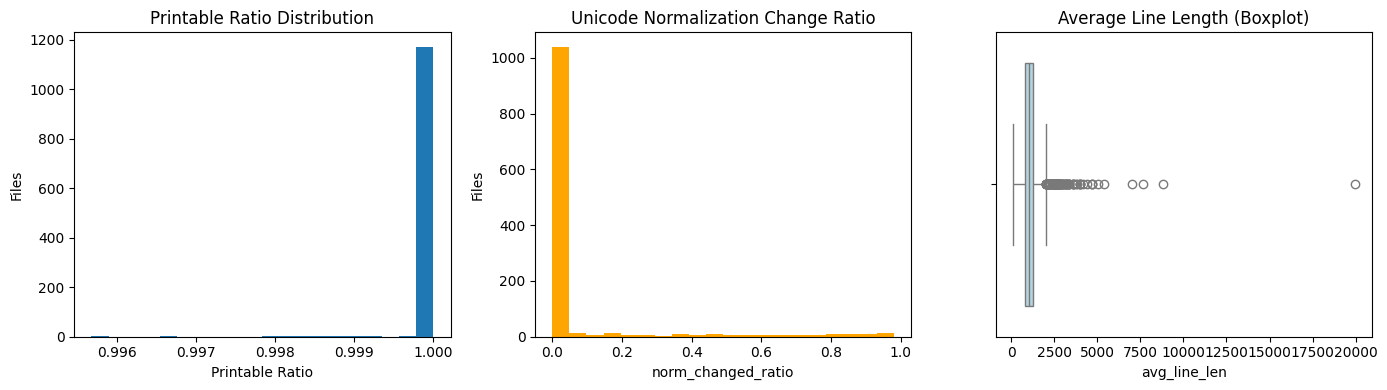

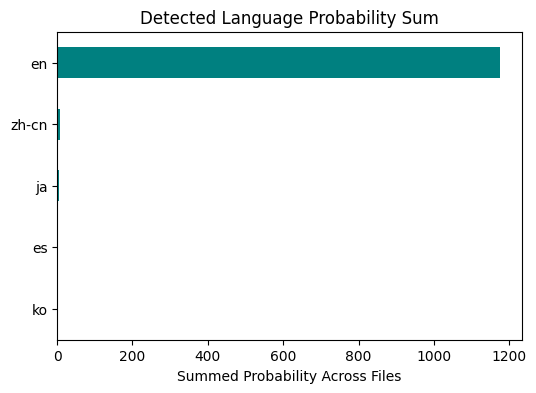

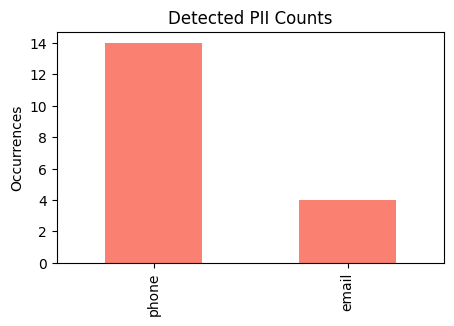

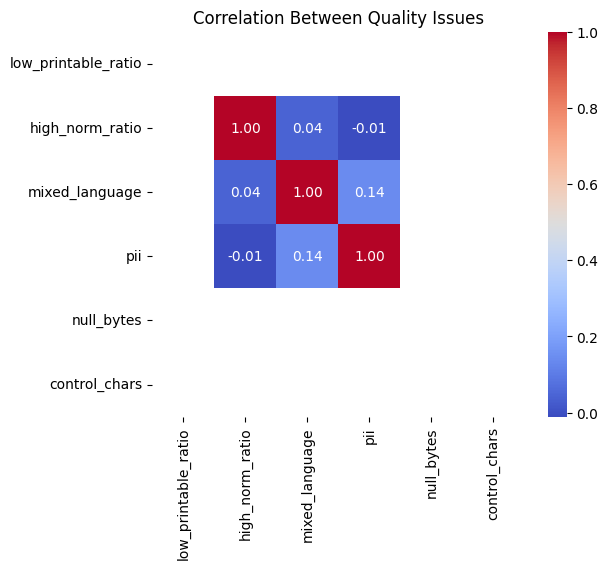


✅ Data Quality Report generated successfully.

Total files analyzed: 1189
Files with potential issues: 120


{'summary':                 Metric  Count
 0          total_files   1189
 1       empty_or_short      0
 2  low_printable_ratio      0
 3      high_norm_ratio    105
 4       mixed_language      3
 5         pii_detected     16
 6        control_chars      0
 7           null_bytes      0
 8            bidi_ctrl      0,
 'issue_counts': {'total_files': 1189,
  'empty_or_short': np.int64(0),
  'low_printable_ratio': 0,
  'high_norm_ratio': np.int64(105),
  'mixed_language': np.int64(3),
  'pii_detected': np.int64(16),
  'control_chars': np.int64(0),
  'null_bytes': np.int64(0),
  'bidi_ctrl': np.int64(0)},
 'corr':                      low_printable_ratio  high_norm_ratio  mixed_language  \
 low_printable_ratio                  NaN              NaN             NaN   
 high_norm_ratio                      NaN         1.000000        0.043431   
 mixed_language                       NaN         0.043431        1.000000   
 pii                                  NaN        -0.010623        0

In [86]:
def generate_quality_report(df: pd.DataFrame ):
    """
    Generate and display an interactive data quality report for Trusted Zone text data.    
    """
    # ---- Validate input ----
    if df.empty:
        print(" The DataFrame is empty. Nothing to analyze.")
        return None

    # ----  Compute key issue counts ----
    df["pii_detected"] = df["pii_hits"].apply(lambda x: sum(x.values()) > 0)
    summary = {
        "total_files": len(df),
        "empty_or_short": (df["empty"] | df["too_short"]).sum(),
        "low_printable_ratio": df[df["printable_ratio"]<0.9].shape[0],
        "high_norm_ratio": (df["norm_changed_ratio"] > 0.3).sum(),
        "mixed_language": df["mixed_language"].sum(),
        "pii_detected": df["pii_detected"].sum(),
        "control_chars": (df["control_char_ratio"] > 0.01).sum(),
        "null_bytes": df["has_null_bytes"].sum(),
        "bidi_ctrl": (df["bidi_ctrl_count"] > 0).sum(),
    }

    summary_df = pd.DataFrame(summary.items(), columns=["Metric", "Count"])
    display(summary_df.style.set_caption("Quality Summary (Key Issue Counts)"))

    # ----  Distributions ----
    plt.figure(figsize=(14, 4))

    plt.subplot(1, 3, 1)
    plt.hist(df["printable_ratio"], bins=20)
    plt.title("Printable Ratio Distribution")
    plt.xlabel("Printable Ratio")
    plt.ylabel("Files")

    plt.subplot(1, 3, 2)
    plt.hist(df["norm_changed_ratio"], bins=20, color='orange')
    plt.title("Unicode Normalization Change Ratio")
    plt.xlabel("norm_changed_ratio")
    plt.ylabel("Files")

    plt.subplot(1, 3, 3)
    sns.boxplot(x=df["avg_line_len"], color='lightblue')
    plt.title("Average Line Length (Boxplot)")
    plt.tight_layout()
    plt.show()

    # ----  Language probability distribution ----
    all_langs = {}
    for d in df["language_probs"]:
        for lang, prob in d.items():
            all_langs[lang] = all_langs.get(lang, 0) + prob
    if all_langs:
        plt.figure(figsize=(6, 4))
        pd.Series(all_langs).sort_values(ascending=True).plot.barh(
            title="Detected Language Probability Sum", color='teal'
        )
        plt.xlabel("Summed Probability Across Files")
        plt.show()

    # ----  PII frequency summary ----
    pii_counts = pd.DataFrame(df["pii_hits"].tolist()).sum().sort_values(ascending=False)
    if pii_counts.sum() > 0:
        plt.figure(figsize=(5, 3))
        pii_counts.plot.bar(title="Detected PII Counts", color='salmon')
        plt.ylabel("Occurrences")
        plt.show()

    # ----  Correlation heatmap between quality issues ----
    issue_flags = pd.DataFrame({
        "low_printable_ratio": df["printable_ratio"] < 0.9,
        "high_norm_ratio": df["norm_changed_ratio"] > 0.3,
        "mixed_language": df["mixed_language"],
        "pii": df["pii_detected"],
        "null_bytes": df["has_null_bytes"],
        "control_chars": df["control_char_ratio"] > 0.01
    }).fillna(0).astype(int)

    corr = issue_flags.corr()
    plt.figure(figsize=(6, 5))
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Correlation Between Quality Issues")
    plt.show()

    # ----  Print summary overview ----
    print("\n Data Quality Report generated successfully.\n")
    print(f"Total files analyzed: {len(df)}")
    low_printable = (df["printable_ratio"].fillna(0) < 0.9)
    high_norm = (df["norm_changed_ratio"].fillna(0) > 0.3)
    pii_detected = df["pii_detected"].fillna(False).astype(bool)
    
    potential_issues = (low_printable | high_norm | pii_detected).sum()
    
    print(f"Files with potential issues: {int(potential_issues)}")
    

,Metric,Count
0,total_files,1189
1,empty_or_short,0
2,low_printable_ratio,0
3,high_norm_ratio,105
4,mixed_language,3
5,pii_detected,16
6,control_chars,0
7,null_bytes,0
8,bidi_ctrl,0


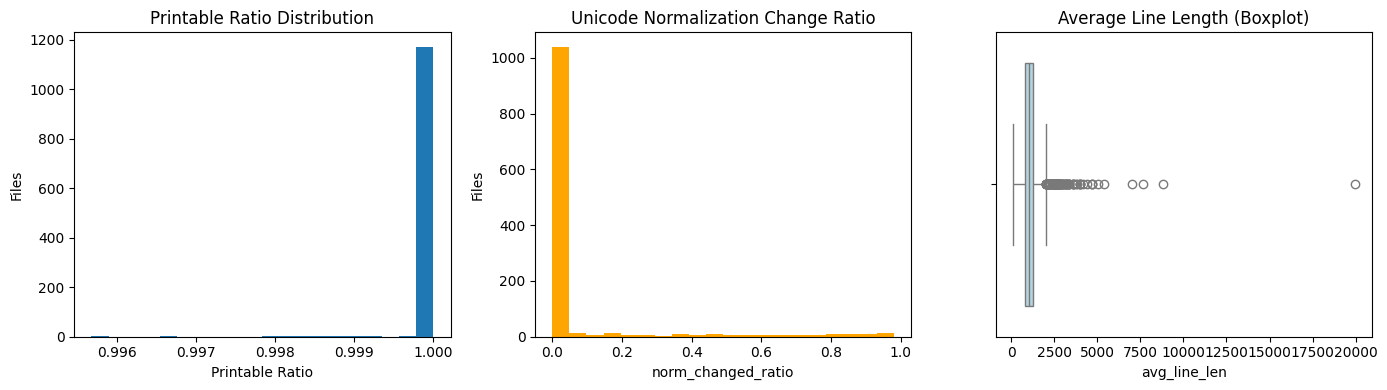

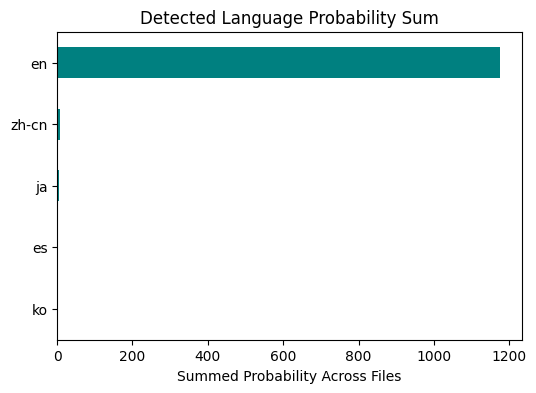

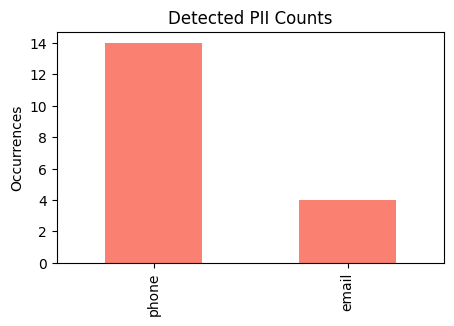

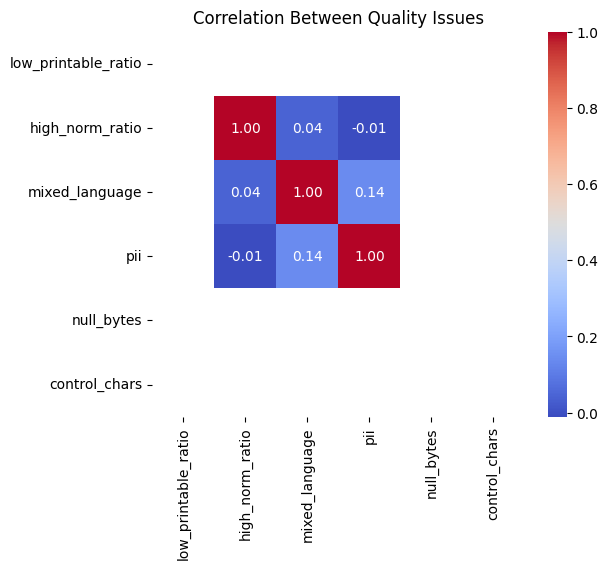


✅ Data Quality Report generated successfully.

Total files analyzed: 1189
Files with potential issues: 120


{'summary':                 Metric  Count
 0          total_files   1189
 1       empty_or_short      0
 2  low_printable_ratio      0
 3      high_norm_ratio    105
 4       mixed_language      3
 5         pii_detected     16
 6        control_chars      0
 7           null_bytes      0
 8            bidi_ctrl      0,
 'issue_counts': {'total_files': 1189,
  'empty_or_short': np.int64(0),
  'low_printable_ratio': 0,
  'high_norm_ratio': np.int64(105),
  'mixed_language': np.int64(3),
  'pii_detected': np.int64(16),
  'control_chars': np.int64(0),
  'null_bytes': np.int64(0),
  'bidi_ctrl': np.int64(0)},
 'corr':                      low_printable_ratio  high_norm_ratio  mixed_language  \
 low_printable_ratio                  NaN              NaN             NaN   
 high_norm_ratio                      NaN         1.000000        0.043431   
 mixed_language                       NaN         0.043431        1.000000   
 pii                                  NaN        -0.010623        0

In [106]:
generate_quality_report(df)

In [87]:
def get_text(bucket, key):
    resp = s3.get_object(Bucket=bucket, Key=key)
    body = resp["Body"].read()
    text = body.decode("utf-8")
    return text



In [92]:
WS_RE = re.compile(r"[ \t\u00A0\u2000-\u200B\u3000]+")

def basic_clean(text: str) -> str:
    # Normalize & strip BOM
    text = unicodedata.normalize("NFKC", text).replace("\ufeff", "")

    # Remove control chars (keep whitespace)
    text = CTRL_RE.sub("", text)

    # Normalize newlines first (helps regex around lines)
    text = text.replace("\r\n", "\n").replace("\r", "\n")

    # PII redaction (email/phone)
    for pattern in PII_PATTERNS.values():
        text = re.sub(pattern, "", text)
        
    # Line-wise whitespace normalization
    #  - collapse runs of spaces/tabs/various unicode spaces into a single space
    #  - strip ends
    text = "\n".join(WS_RE.sub(" ", ln).strip() for ln in text.split("\n"))

    # Fix artifacts after redaction: dangling @, +, (), multiple spaces, stray punctuation
    text = re.sub(r"\s{2,}", " ", text)                 # collapse multi-spaces
    text = re.sub(r"\s+([,.;:?!])", r"\1", text)        # remove space before punctuation
    text = re.sub(r"([(@+])\s*(?=[)@+.,;:!?])", r"", text)  # clear leftover symbols clusters
    text = re.sub(r"\n{3,}", "\n\n", text)              # collapse excessive blank lines


    return text


In [91]:
HIGH_UNICODE_GARBAGE_RE = re.compile(r"[^\x00-\x7F]+")
COMBINING_MARKS_RE = re.compile(r'[\u0300-\u036F]+')     # combining marks

try:
    import emoji
    EMOJI_RE = emoji.get_emoji_regexp()
except Exception:
    EMOJI_RE = re.compile(r'[\U0001F300-\U0001FAFF\U00002700-\U000027BF]+')
    
    
REPLACE_TO_ASCII = {
    "\u2018": "'", "\u2019": "'", "\u201C": '"', "\u201D": '"',
    "\u2013": "-", "\u2014": "-", "\u2212": "-", "\u00A0": " ",
}

def _map_preferred_ascii(s: str) -> str:
    if not s:
        return s
    return s.translate(str.maketrans(REPLACE_TO_ASCII))

def deep_clean(text: str, ascii_only: bool = True, remove_emoji: bool = True, drop_combining: bool = True) -> str:
    """
    Aggressive cleanup. Use AFTER translation to English.
    """
    #  Prefer ASCII-friendly replacements before filtering
    text = _map_preferred_ascii(text)
    #  Remove emoji (optional)
    if remove_emoji:
        text = EMOJI_RE.sub(" ", text)
    # Remove combining marks (optional)
    if drop_combining:
        text = COMBINING_MARKS_RE.sub("", text)
    #  Enforce ASCII-only (optional & aggressive)
    if ascii_only:
        text = HIGH_UNICODE_GARBAGE_RE.sub(" ", text)
    # Final tidy
    text = unicodedata.normalize("NFKC", text)  # keep stability
    text = CTRL_RE.sub(" ", text)
    text = re.sub(r"\s{2,}", " ", text).strip()
    text = re.sub(r"\n{3,}", "\n\n", text)
    return text

In [90]:
LANG_MAP = {
    "zh-cn": "zh-CN",
    "zh_cn": "zh-CN",
    "zh-CN": "zh-CN",
    "zh": "zh-CN",
    "en": "en",
    "es": "es",
    "fr": "fr",
    "ja": "ja",
    "ko": "ko"
}   
def to_english(text: str, lang, sentence = False) -> str:
    try:
        if not sentence:
            src_lang = LANG_MAP.get(lang.lower(), lang)
            result =  GoogleTranslator(source=src_lang, target='en').translate(text)
        else:
            result = GoogleTranslator(source="auto", target='en').translate(text)
        return result, True
    except Exception as e:
        print(f"Translation failed ({e}), keeping original text.")
        return text, False


        


In [93]:
_SENT_SPLIT_RE = re.compile(
    r'(?:\s*\n+\s*)|'                 # paragraph/newline breaks
    r'(?<=[。！？!?])\s+'              # CJK sentence enders + whitespace
    r'|(?<=[\.\?\!])\s+'              # English . ? ! + whitespace
)

def split_into_sentences(text: str) -> List[str]:

    text = re.sub(r'\r\n?', '\n', text).strip()
    parts = []
    for para in filter(None, text.split('\n')):
        para = re.sub(r'\s+', ' ', para).strip()
        if not para:
            continue
        parts.extend([s.strip() for s in re.split(_SENT_SPLIT_RE, para) if s.strip()])
    return parts

def chunk_text_with_token_budget(
    text: str,
    tokenizer,
    max_tokens: int = 512,
    stride: int = 64,
    reserve_special: int = 2,  # reserve tokens for [CLS]/[SEP] or similar
) -> List[Dict]:
    
    # The actual available token budget after reserving special tokens
    budget = max_tokens - reserve_special
    assert budget > 0, "max_tokens is too small; cannot reserve special tokens"
    
    # Split text into sentences
    sents = split_into_sentences(text)

    chunks: List[Dict] = []
    curr_sents: List[str] = []
    curr_tokens = 0

    # Helper: count token length for a given text (excluding special tokens)
    def token_len(txt: str) -> int:
        return len(tokenizer.encode(txt))

    # Precompute token lengths of all sentences for efficiency
    sent_lens = [token_len(s) for s in sents]

    i = 0
    while i < len(sents):
        s = sents[i]
        s_len = sent_lens[i]

        # Case A: single sentence exceeds budget → split within sentence (sliding window)
        if s_len > budget:
            # If current chunk buffer is not empty, finalize it first
            if curr_sents:
                chunk_text = " ".join(curr_sents).strip()
                chunks.append({"text": chunk_text, "n_tokens": token_len(chunk_text), "input_ids": None})
                curr_sents, curr_tokens = [], 0

            # Encode the long sentence into token IDs
            input_ids = tokenizer.encode(s)
            start = 0
            while start < len(input_ids):
                # Take a slice of up to `budget` tokens
                end = min(start + budget, len(input_ids))
                piece_ids = input_ids[start:end]
                # Decode back to text for saving
                piece_text = tokenizer.decode(piece_ids).strip()
                chunks.append({"text": piece_text, "n_tokens": len(piece_ids), "input_ids": None})

                # If reached the end, stop
                if end == len(input_ids):
                    break
                # Move window forward with overlap (`stride`)
                start = max(end - stride, start + 1)
            i += 1
            continue

        # Case B: greedy packing — keep adding sentences to current chunk
        if curr_tokens + s_len <= budget:
            curr_sents.append(s)
            curr_tokens += s_len
            i += 1
        else:
            # Finalize the current chunk when adding the next sentence would exceed the budget
            chunk_text = " ".join(curr_sents).strip()
            chunks.append({"text": chunk_text, "n_tokens": token_len(chunk_text), "input_ids": None})
            curr_sents, curr_tokens = [], 0

    # Finalize any remaining sentences
    if curr_sents:
        chunk_text = " ".join(curr_sents).strip()
        chunks.append({"text": chunk_text, "n_tokens": token_len(chunk_text), "input_ids": None})

    return chunks

In [98]:
def clean_text(client, df,max_tokens = 512):
    bucket="trusted-zone"
    tokenizer = tiktoken.get_encoding("cl100k_base")
    for row in df.itertuples(index = False):

        
        #check text need remove or clean
        if row.empty or row.too_short or row.printable_ratio < 0.9 or row.duplicated:
            client.delete_object(Bucket=bucket, Key=row.key)
            continue
        #get text
        text = get_text("trusted-zone",row.key)        
        #basic clean and get text
        text = basic_clean(text)

        # Language gate: decide whether this document likely needs translation to English
        # Uses overall English probability from row.language_probs; if below 0.85, enable translation.
        should_translate = False
        prob = row.language_probs.get("en",0)
        if prob < 0.85:
            should_translate = True
            
        # Split the full text by blank lines into paragraphs (preserve only non-empty ones)
        paragraphs = [p.strip() for p in text.split("\n\n") if p.strip()]
        for i in range(0, len(paragraphs )):
            # Translate before token-based chunking:
            # doing translation first avoids re-breaking chunks after token counts change due to translation.
            if should_translate:
                paragraph = paragraphs[i]
                # Detect the source language at the paragraph level (more precise than doc-level for mixed content)
                source = detect(paragraph)

                # If this paragraph is not English, attempt paragraph-level translation first
                if (source != "en"):
                    # Primary attempt: translate the whole paragraph
                    result, sucess = to_english(paragraph, source)

                    # Fallback: if paragraph translation fails, translate sentence-by-sentence and then aggregate back
                    if not sucess:
                        senteces = split_into_sentences(paragraph)
                        translated_sentences = []
                        for sent in senteces:
                            source = detect(sent)
                            translated = to_english(sent, source, sentence=True)
                            translated_sentences.append(translated.strip())

                        # Reassemble the paragraph from translated sentences (simple space join)
                        result = ".".join(s for s in translated_sentences if s)

                    # Replace the original paragraph with the translated result
                    paragraphs[i] = result

            # Token-length control:
            # If the original paragraph's token count exceeded `max_tokens`, chunk the (possibly translated) paragraph.
            chunks = chunk_text_with_token_budget(paragraphs[i], tokenizer, max_tokens)
            # Join chunks with double newlines to preserve a visual boundary between slices
            full_text = "\n\n".join(chunk["text"].strip() for chunk in chunks if chunk["text"].strip())
            paragraphs[i] = full_text
                
        # Reassemble the full text by joining paragraphs with blank lines
        text = "\n\n".join(paragraphs)
        
        # Post-translation validation:
        # Check language again to verify the text is predominantly English and not mixed-language.
        language_probs,mixed_languages=language_check(text)
        
        # Last-resort cleanup:
        # If still mixed-language or English probability is too low, try textual fixes and deep cleaning,
        # then re-check. If still not acceptable, delete the object.
        # (Typical causes: rare code fragments, heavy non-ASCII characters, odd punctuation.)
        if (mixed_languages or language_probs.get("en", 0) < 0.95):
            fixed = fix_text(text)
            text = deep_clean(fixed)
            language_probs, mixed_languages = language_check(text)
            # Final rejection if it still fails the language criteria
            if (mixed_languages or language_probs.get("en", 0) < 0.95):
                client.delete_object(Bucket=bucket, Key=row.key)
                continue
        # accept text
        client.put_object(
            Bucket=bucket,
            Key=row.key,  # Make sure the file key (path) is correct
            Body=text.encode('utf-8'),
            ContentType="text/plain"
        )
        print(f"Normalized: {row.key}")

        
        
            
clean_text(s3, df)

Normalized: texts/text_1761318441201.txt
Normalized: texts/text_1761318441420.txt
Normalized: texts/text_1761318441651.txt
Normalized: texts/text_1761318441842.txt
Normalized: texts/text_1761318442105.txt
Normalized: texts/text_1761318442428.txt
Normalized: texts/text_1761318442717.txt
Normalized: texts/text_1761318443051.txt
Normalized: texts/text_1761318443246.txt
Normalized: texts/text_1761318443504.txt
Normalized: texts/text_1761318443760.txt
Normalized: texts/text_1761318443942.txt
Normalized: texts/text_1761318444105.txt
Normalized: texts/text_1761318444325.txt
Normalized: texts/text_1761318444510.txt
Normalized: texts/text_1761318444659.txt
Normalized: texts/text_1761318444935.txt
Normalized: texts/text_1761318445128.txt
Normalized: texts/text_1761318445422.txt
Normalized: texts/text_1761318445743.txt
Normalized: texts/text_1761318446001.txt
Normalized: texts/text_1761318446362.txt
Normalized: texts/text_1761318446568.txt
Normalized: texts/text_1761318446766.txt
Normalized: text

In [113]:
data_clean = extract_datas(bucket = "trusted-zone", prefix = "texts")


,Metric,Count
0,total_files,988
1,empty_or_short,0
2,low_printable_ratio,0
3,high_norm_ratio,1
4,mixed_language,1
5,pii_detected,0
6,control_chars,0
7,null_bytes,0
8,bidi_ctrl,0


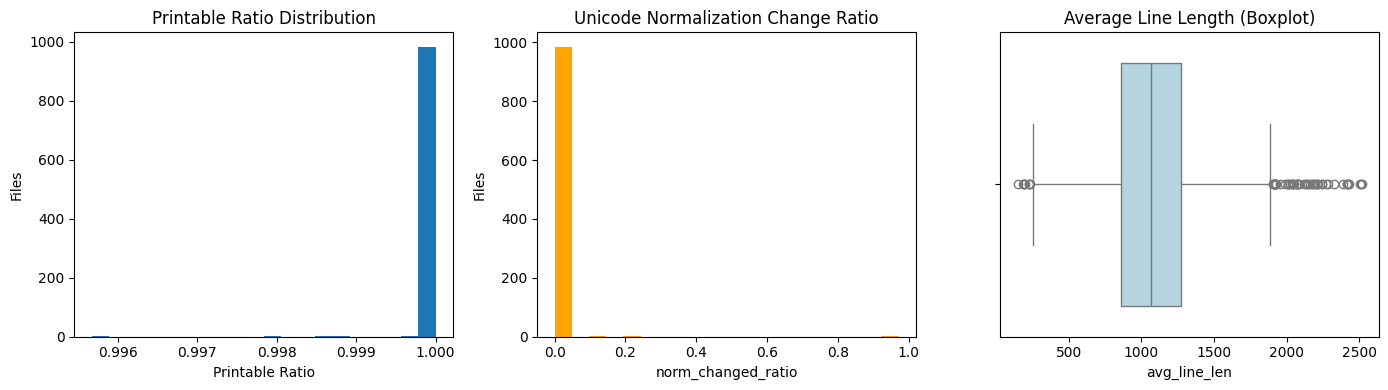

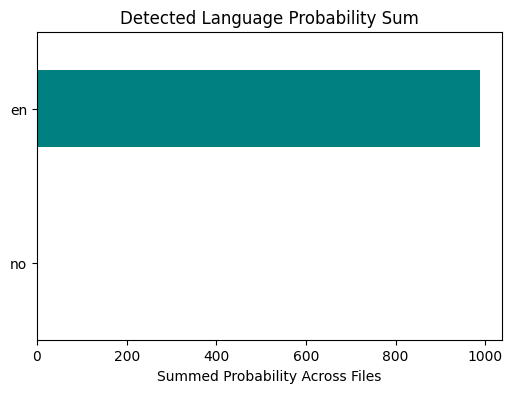

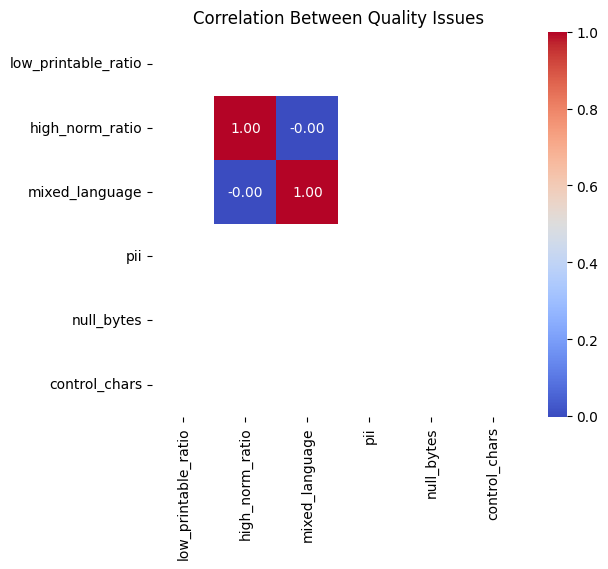


✅ Data Quality Report generated successfully.

Total files analyzed: 988
Files with potential issues: 1


{'summary':                 Metric  Count
 0          total_files    988
 1       empty_or_short      0
 2  low_printable_ratio      0
 3      high_norm_ratio      1
 4       mixed_language      1
 5         pii_detected      0
 6        control_chars      0
 7           null_bytes      0
 8            bidi_ctrl      0,
 'issue_counts': {'total_files': 988,
  'empty_or_short': np.int64(0),
  'low_printable_ratio': 0,
  'high_norm_ratio': np.int64(1),
  'mixed_language': np.int64(1),
  'pii_detected': np.int64(0),
  'control_chars': np.int64(0),
  'null_bytes': np.int64(0),
  'bidi_ctrl': np.int64(0)},
 'corr':                      low_printable_ratio  high_norm_ratio  mixed_language  \
 low_printable_ratio                  NaN              NaN             NaN   
 high_norm_ratio                      NaN         1.000000       -0.001013   
 mixed_language                       NaN        -0.001013        1.000000   
 pii                                  NaN              NaN             

In [117]:
# Convert the data into a dataFrame
df_clean = pd.DataFrame(data_clean)
generate_quality_report(df_clean)